In [114]:
# Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats as st

# # Load datasets from local files into pandas DataFrames
df_users = pd.read_csv("megaline-data/megaline_users.csv")
df_calls = pd.read_csv("megaline-data/megaline_calls.csv")
df_messages = pd.read_csv("megaline-data/megaline_messages.csv")
df_internet = pd.read_csv("megaline-data/megaline_internet.csv")
df_plans = pd.read_csv("megaline-data/megaline_plans.csv")

In [115]:
# Display the first rows of the users dataset to understand its structure
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN


In [116]:
# Display the first rows of the calls dataset to examine call records
df_calls.head()

,id,user_id,call_date,duration
0,1000_93,1000,2018-12-27,8.52
1,1000_145,1000,2018-12-27,13.66
2,1000_247,1000,2018-12-27,14.48
3,1000_309,1000,2018-12-28,5.76
4,1000_380,1000,2018-12-30,4.22


In [117]:
# Display the first rows of the messages dataset to review SMS activity
df_messages.head()

,id,user_id,message_date
0,1000_125,1000,2018-12-27
1,1000_160,1000,2018-12-31
2,1000_223,1000,2018-12-31
3,1000_251,1000,2018-12-27
4,1000_255,1000,2018-12-26


In [118]:
# Display the first rows of the internet dataset to analyze data usage
df_internet.head()

,id,user_id,session_date,mb_used
0,1000_13,1000,2018-12-29,89.86
1,1000_204,1000,2018-12-31,0.00
2,1000_379,1000,2018-12-28,660.40
3,1000_413,1000,2018-12-26,270.99
4,1000_442,1000,2018-12-27,880.22


In [119]:
# Display the first rows of the plans dataset to understand plan details
df_plans.head()

,messages_included,mb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15360,500,20,10,0.03,0.03,surf
1,1000,30720,3000,70,7,0.01,0.01,ultimate


In [120]:
# Display general information about the users dataset (data types, missing values, etc.)
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [121]:
# Display general information about the calls dataset to examine structure and completeness
df_calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [122]:
# Display general information about the messages dataset to identify potential issues
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [123]:
# Display general information about the messages dataset to identify potential issues
df_messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [124]:
# Display general information about the plans dataset to review plan characteristics
df_plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 260.0+ bytes


In [125]:
# Convert data allowance from megabytes (MB) to gigabytes (GB)

# Get the position of the original column
pos = df_plans.columns.get_loc('mb_per_month_included')

# Create a new column in GB
df_plans.insert(pos, 'gb_per_month_included', df_plans['mb_per_month_included'] / 1024)

# Ensure the new column has float data type
df_plans['gb_per_month_included'] = df_plans['gb_per_month_included'].astype(float)

# Drop the original column in MB
df_plans = df_plans.drop(columns=['mb_per_month_included'])

# Display updated plans dataset
df_plans.head()

,messages_included,gb_per_month_included,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute,plan_name
0,50,15.0,500,20,10,0.03,0.03,surf
1,1000,30.0,3000,70,7,0.01,0.01,ultimate


In [126]:
# Rename column for consistency
df_plans.rename(columns={'usd_monthly_pay': 'usd_monthly_fee'}, inplace=True)

In [127]:
# Calculate derived metrics to better compare plan value

# Effective cost per GB included in the plan
df_plans['usd_per_gb_real'] = (
    df_plans['usd_monthly_fee'] / df_plans['gb_per_month_included']
).round(3)

# Effective cost per included message
df_plans['usd_per_message_included'] = (
    df_plans['usd_monthly_fee'] / df_plans['messages_included']
).round(4)

# Effective cost per included minute
df_plans['usd_per_minute_included'] = (
    df_plans['usd_monthly_fee'] / df_plans['minutes_included']
).round(4)

# Overall plan value: total included services per dollar
df_plans['plan_value'] = (
    (df_plans['messages_included'] +
     df_plans['minutes_included'] +
     df_plans['gb_per_month_included'])
    / df_plans['usd_monthly_fee']
).round(3)

# Display updated dataset
df_plans.head()

,messages_included,gb_per_month_included,minutes_included,usd_monthly_fee,usd_per_gb,usd_per_message,usd_per_minute,plan_name,usd_per_gb_real,usd_per_message_included,usd_per_minute_included,plan_value
0,50,15.0,500,20,10,0.03,0.03,surf,1.333,0.40,0.0400,28.250
1,1000,30.0,3000,70,7,0.01,0.01,ultimate,2.333,0.07,0.0233,57.571


In [128]:
# Convert the registration date column to datetime format (handle potential errors)
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'], format='%Y-%m-%d', errors='coerce')

# Display general information about the users dataset to verify the datatime format
df_users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan        500 non-null    object        
 7   churn_date  34 non-null     object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 31.4+ KB


In [129]:
# User Data Processing
# The registration date is converted to datetime format, and new features are created 
# to enable time-based analysis. Additionally, a user status variable is defined 
# based on whether the user has churned or remains active.

# Extract year, month, day, and weekday from reg_date
df_users['reg_year_u'] = df_users['reg_date'].dt.year
df_users['reg_month_u'] = df_users['reg_date'].dt.month
df_users['reg_day_u'] = df_users['reg_date'].dt.day
df_users['reg_weekday_u'] = df_users['reg_date'].dt.day_name()

# Create a year-month column for monthly analysis (format: YYYY-MM)
df_users['reg_year_month_u'] = df_users['reg_date'].dt.strftime('%Y-%m')

# Create a user status column based on churn_date
df_users['status'] = df_users['churn_date'].isna().map({True: 'active', False: 'churned'})

# Display updated dataset
df_users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,reg_year_u,reg_month_u,reg_day_u,reg_weekday_u,reg_year_month_u,status
0,1000,Anamaria,Bauer,45,"Atlanta-Sandy Springs-Roswell, GA MSA",2018-12-24,ultimate,NaN,2018,12,24,Monday,2018-12,active
1,1001,Mickey,Wilkerson,28,"Seattle-Tacoma-Bellevue, WA MSA",2018-08-13,surf,NaN,2018,8,13,Monday,2018-08,active
2,1002,Carlee,Hoffman,36,"Las Vegas-Henderson-Paradise, NV MSA",2018-10-21,surf,NaN,2018,10,21,Sunday,2018-10,active
3,1003,Reynaldo,Jenkins,52,"Tulsa, OK MSA",2018-01-28,surf,NaN,2018,1,28,Sunday,2018-01,active
4,1004,Leonila,Thompson,40,"Seattle-Tacoma-Bellevue, WA MSA",2018-05-23,surf,NaN,2018,5,23,Wednesday,2018-05,active


In [130]:
# Call Data Processing
# The call date is converted to datetime format, and additional time-based features 
# are extracted. Call durations are rounded up to the nearest minute according to 
# billing rules to accurately reflect charged usage.

# Convert the call_date column to datetime format
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'], format='%Y-%m-%d')

# Extract date-related features
df_calls['year_c'] = df_calls['call_date'].dt.year
df_calls['month_c'] = df_calls['call_date'].dt.month
df_calls['day_c'] = df_calls['call_date'].dt.day
df_calls['weekday_c'] = df_calls['call_date'].dt.day_name()

# Create a year-month column for monthly aggregation (format: YYYY-MM)
df_calls['year_month_c'] = df_calls['call_date'].dt.strftime('%Y-%m')

# Round call duration up to the next whole minute (billing rule)
def round_up_minutes(duration):
    if duration == 0:
        return 0
    else:
        return np.ceil(duration)

df_calls['billed_minutes'] = df_calls['duration'].apply(round_up_minutes)

# Convert billed minutes to integer type
df_calls['billed_minutes'] = df_calls['billed_minutes'].astype(int)

# Display sample of the processed dataset
df_calls.head(20)

,id,user_id,call_date,duration,year_c,month_c,day_c,weekday_c,year_month_c,billed_minutes
0,1000_93,1000,2018-12-27,8.52,2018,12,27,Thursday,2018-12,9
1,1000_145,1000,2018-12-27,13.66,2018,12,27,Thursday,2018-12,14
2,1000_247,1000,2018-12-27,14.48,2018,12,27,Thursday,2018-12,15
3,1000_309,1000,2018-12-28,5.76,2018,12,28,Friday,2018-12,6
4,1000_380,1000,2018-12-30,4.22,2018,12,30,Sunday,2018-12,5
5,1000_388,1000,2018-12-31,2.20,2018,12,31,Monday,2018-12,3
6,1000_510,1000,2018-12-27,5.75,2018,12,27,Thursday,2018-12,6
7,1000_521,1000,2018-12-28,14.18,2018,12,28,Friday,2018-12,15
8,1000_530,1000,2018-12-28,5.77,2018,12,28,Friday,2018-12,6
9,1000_544,1000,2018-12-26,4.40,2018,12,26,Wednesday,2018-12,5


In [131]:
# Message Data Processing
# The message date is converted to datetime format, and additional time-based features 
# are extracted to support monthly and daily analysis.

# Convert the message_date column to datetime format
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'], format='%Y-%m-%d')

# Extract date-related features
df_messages['year_m'] = df_messages['message_date'].dt.year
df_messages['month_m'] = df_messages['message_date'].dt.month
df_messages['day_m'] = df_messages['message_date'].dt.day
df_messages['weekday_m'] = df_messages['message_date'].dt.day_name()

# Create a year-month column for monthly aggregation (format: YYYY-MM)
df_messages['year_month_m'] = df_messages['message_date'].dt.strftime('%Y-%m')

# Display a sample of the processed dataset
df_messages.head(10)

,id,user_id,message_date,year_m,month_m,day_m,weekday_m,year_month_m
0,1000_125,1000,2018-12-27,2018,12,27,Thursday,2018-12
1,1000_160,1000,2018-12-31,2018,12,31,Monday,2018-12
2,1000_223,1000,2018-12-31,2018,12,31,Monday,2018-12
3,1000_251,1000,2018-12-27,2018,12,27,Thursday,2018-12
4,1000_255,1000,2018-12-26,2018,12,26,Wednesday,2018-12
5,1000_346,1000,2018-12-29,2018,12,29,Saturday,2018-12
6,1000_386,1000,2018-12-30,2018,12,30,Sunday,2018-12
7,1000_413,1000,2018-12-31,2018,12,31,Monday,2018-12
8,1000_502,1000,2018-12-27,2018,12,27,Thursday,2018-12
9,1000_525,1000,2018-12-28,2018,12,28,Friday,2018-12


In [132]:
# Internet Data Processing
# The session date is converted to datetime format, and monthly data usage is aggregated per user.
# Total monthly usage is converted from MB to GB and rounded up according to billing rules.

# Convert session_date to datetime format
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

# Extract date-related features
df_internet['year_i'] = df_internet['session_date'].dt.year
df_internet['month_i'] = df_internet['session_date'].dt.month
df_internet['day_i'] = df_internet['session_date'].dt.day

# Create a year-month column for monthly aggregation (format: YYYY-MM)
df_internet['year_month_i'] = df_internet['session_date'].dt.strftime('%Y-%m')

# Aggregate total MB used per user per month
df_monthly_internet = (
    df_internet.groupby(['user_id', 'year_i', 'month_i'], as_index=False)['mb_used']
    .sum()
)

# Calculate billed GB (rounding up monthly usage)
df_monthly_internet['gb_billed'] = np.ceil(
    df_monthly_internet['mb_used'] / 1024
).astype(int)

# Display a sample of the aggregated dataset
df_monthly_internet.head()

,user_id,year_i,month_i,mb_used,gb_billed
0,1000,2018,12,1901.47,2
1,1001,2018,8,6919.15,7
2,1001,2018,9,13314.82,14
3,1001,2018,10,22330.49,22
4,1001,2018,11,18504.30,19


In [133]:
# Monthly Call Usage Aggregation
# Calculate the total number of billed minutes used by each user per month.

df_monthly_minutes_calls = (
    df_calls
    .groupby(['user_id', 'year_month_c'])['billed_minutes']
    .sum()
    .reset_index(name='monthly_minutes_calls')
)

# Display a sample of the aggregated dataset
df_monthly_minutes_calls.head()

,user_id,year_month_c,monthly_minutes_calls
0,1000,2018-12,124
1,1001,2018-08,182
2,1001,2018-09,315
3,1001,2018-10,393
4,1001,2018-11,426


In [134]:
# Monthly Message Usage Aggregation
# Calculate the total number of messages sent by each user per month.

df_monthly_messages = (
    df_messages
    .groupby(['user_id', 'year_month_m'])['id']
    .count()
    .reset_index(name='monthly_messages')
)

# Display a sample of the aggregated dataset
df_monthly_messages.head()

,user_id,year_month_m,monthly_messages
0,1000,2018-12,11
1,1001,2018-08,30
2,1001,2018-09,44
3,1001,2018-10,53
4,1001,2018-11,36


In [135]:
# Monthly Internet Usage Aggregation
# Calculate the total volume of internet data used (in MB) by each user per month.

monthly_internet = (
    df_internet
    .groupby(['user_id', 'year_month_i'])['mb_used']
    .sum()
    .reset_index(name='monthly_mb_used')
)

# Convert MB to GB using billing rule (round up per month)
monthly_internet['gb_billed'] = np.ceil(monthly_internet['monthly_mb_used'] / 1024).astype(int)

# Keep only necessary columns for merging
monthly_internet = monthly_internet[['user_id', 'year_month_i', 'gb_billed']]

# Preview
monthly_internet.head()

,user_id,year_month_i,gb_billed
0,1000,2018-12,2
1,1001,2018-08,7
2,1001,2018-09,14
3,1001,2018-10,22
4,1001,2018-11,19


In [136]:

# Monthly Usage Consolidation
# Merge monthly call, message, and internet usage per user.
# Missing values are filled with 0.

# Rename month columns for consistency
df_monthly_minutes_calls = df_monthly_minutes_calls.rename(columns={'year_month_c': 'year_month'})
df_monthly_messages = df_monthly_messages.rename(columns={'year_month_m': 'year_month'})
monthly_internet = monthly_internet.rename(columns={'year_month_i': 'year_month'})

# Merge datasets on user_id and year_month
usage = (
    df_monthly_minutes_calls
    .merge(df_monthly_messages, on=['user_id', 'year_month'], how='outer')
    .merge(monthly_internet, on=['user_id', 'year_month'], how='outer')
)

# Fill missing values with 0
usage[['monthly_minutes_calls', 'monthly_messages', 'gb_billed']] = (
    usage[['monthly_minutes_calls', 'monthly_messages', 'gb_billed']]
    .fillna(0)
)

# Convert gb_billed to integer (clean format)
usage['gb_billed'] = usage['gb_billed'].astype(int)

# Display a sample of the merged dataset
usage.head()

,user_id,year_month,monthly_minutes_calls,monthly_messages,gb_billed
0,1000,2018-12,124.0,11.0,2
1,1001,2018-08,182.0,30.0,7
2,1001,2018-09,315.0,44.0,14
3,1001,2018-10,393.0,53.0,22
4,1001,2018-11,426.0,36.0,19


In [137]:
# Merge monthly usage data
usage = df_monthly_minutes_calls.merge(
    df_monthly_messages,
    on=['user_id', 'year_month'],
    how='outer'
).merge(
    monthly_internet,
    on=['user_id', 'year_month'],
    how='outer'
)

# Fill missing values with 0
usage[['monthly_minutes_calls', 'monthly_messages', 'gb_billed']] = (
    usage[['monthly_minutes_calls', 'monthly_messages', 'gb_billed']].fillna(0)
)

# Merge user plan information
usage = usage.merge(
    df_users[['user_id', 'plan']],
    on='user_id',
    how='left'
)

# Merge plan details
usage = usage.merge(
    df_plans,
    left_on='plan',
    right_on='plan_name',
    how='left'
)

# Remove redundant column
usage = usage.drop(columns=['plan_name'])

usage.head()

,user_id,year_month,monthly_minutes_calls,monthly_messages,gb_billed,plan,messages_included,gb_per_month_included,minutes_included,usd_monthly_fee,usd_per_gb,usd_per_message,usd_per_minute,usd_per_gb_real,usd_per_message_included,usd_per_minute_included,plan_value
0,1000,2018-12,124.0,11.0,2.0,ultimate,1000,30.0,3000,70,7,0.01,0.01,2.333,0.07,0.0233,57.571
1,1001,2018-08,182.0,30.0,7.0,surf,50,15.0,500,20,10,0.03,0.03,1.333,0.40,0.0400,28.250
2,1001,2018-09,315.0,44.0,14.0,surf,50,15.0,500,20,10,0.03,0.03,1.333,0.40,0.0400,28.250
3,1001,2018-10,393.0,53.0,22.0,surf,50,15.0,500,20,10,0.03,0.03,1.333,0.40,0.0400,28.250
4,1001,2018-11,426.0,36.0,19.0,surf,50,15.0,500,20,10,0.03,0.03,1.333,0.40,0.0400,28.250


In [138]:
# Monthly Revenue Calculation
# Revenue = base plan fee + extra charges for exceeding plan limits

# Ensure no missing values in usage columns
usage[['monthly_minutes_calls', 'monthly_messages', 'gb_billed']] = (
    usage[['monthly_minutes_calls', 'monthly_messages', 'gb_billed']].fillna(0)
)

# Calculate extra usage beyond plan limits
usage['extra_minutes'] = (usage['monthly_minutes_calls'] - usage['minutes_included']).clip(lower=0)
usage['extra_messages'] = (usage['monthly_messages'] - usage['messages_included']).clip(lower=0)
usage['extra_gb'] = (usage['gb_billed'] - usage['gb_per_month_included']).clip(lower=0)

# Calculate extra costs
usage['cost_extra_minutes'] = usage['extra_minutes'] * usage['usd_per_minute']
usage['cost_extra_messages'] = usage['extra_messages'] * usage['usd_per_message']
usage['cost_extra_gb'] = usage['extra_gb'] * usage['usd_per_gb']

# Calculate total monthly revenue
usage['monthly_revenue'] = (
    usage['usd_monthly_fee'] +
    usage['cost_extra_minutes'] +
    usage['cost_extra_messages'] +
    usage['cost_extra_gb']
).round(2)

# Display result
usage[['user_id', 'year_month', 'monthly_revenue']].head()

,user_id,year_month,monthly_revenue
0,1000,2018-12,70.00
1,1001,2018-08,20.00
2,1001,2018-09,20.00
3,1001,2018-10,90.09
4,1001,2018-11,60.00


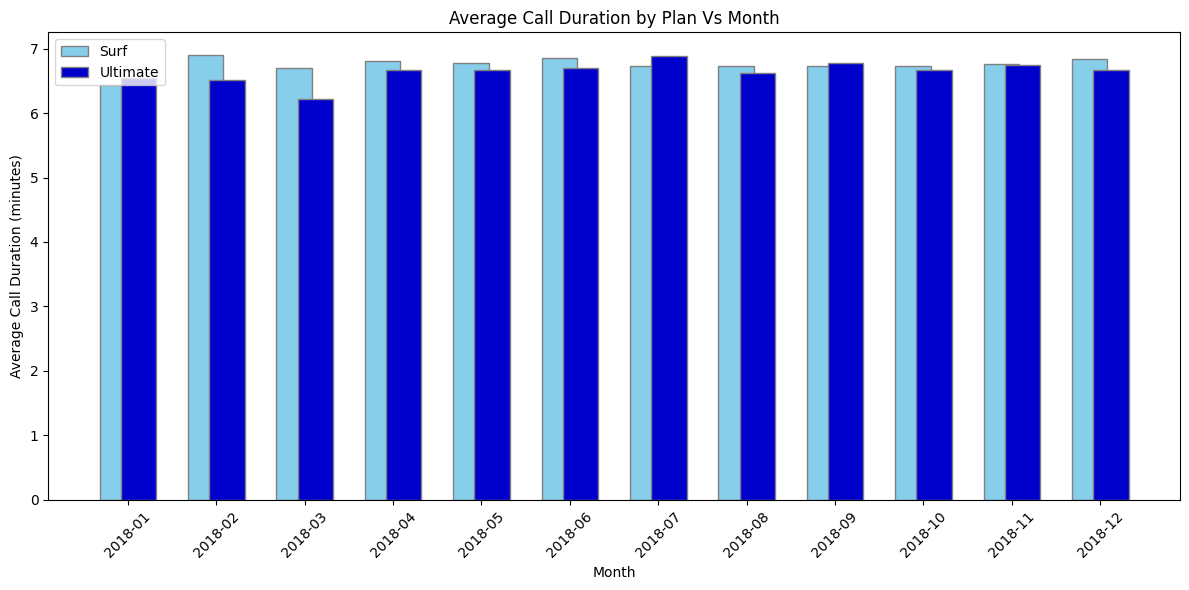

In [139]:
# In this section, we analyze the average call duration per month for users in the Surf and Ultimate plans. 
# The goal is to understand whether there are differences in calling behavior between both plans over time, which may help identify usage patterns and support future revenue analysis.
# We merge call data with user plan information, create a consistent monthly time format, and then calculate the average call duration grouped by plan and month. 
# Finally, we visualize the comparison using a bar chart.

# Merge calls with user plan information
df_calls_merged = df_calls.merge(
    df_users[['user_id', 'plan']],
    on='user_id',
    how='left'
)

# Ensure consistent plan naming
df_calls_merged['plan'] = df_calls_merged['plan'].str.capitalize()

# Create year-month column for monthly analysis
df_calls_merged['year_month'] = pd.to_datetime(df_calls['call_date']).dt.to_period('M').astype(str)

# Calculate average call duration per plan and month
avg_call_duration = (
    df_calls_merged.groupby(['plan', 'year_month'])['duration']
    .mean()
    .reset_index()
)

# Define colors for plans
plan_colors = {'Surf': 'skyblue', 'Ultimate': 'mediumblue'}

# Prepare plotting structure
unique_months = sorted(avg_call_duration['year_month'].unique())
x = np.arange(len(unique_months))
width = 0.4

plt.figure(figsize=(12, 6))

for i, plan in enumerate(['Surf', 'Ultimate']):
    df_plan = avg_call_duration[avg_call_duration['plan'] == plan]
    df_plan = df_plan.set_index('year_month').reindex(unique_months).reset_index()

    plt.bar(
        x + (i * width * 0.6),
        df_plan['duration'].fillna(0),
        width=width,
        label=plan,
        color=plan_colors[plan],
        edgecolor='gray'
    )

plt.xlabel('Month')
plt.ylabel('Average Call Duration (minutes)')
plt.title('Average Call Duration by Plan Vs Month')
plt.xticks(x + width * 0.3, unique_months, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

📊 Conclusion – Bar Chart (Average Call Duration by Plan vs Month)

The bar chart shows that both Surf and Ultimate users have a very similar average call duration across all months, generally between 6 and 7 minutes. Although Surf users are slightly higher in some months, the difference is minimal (less than one minute). This indicates consistent behavior between both plans over time.

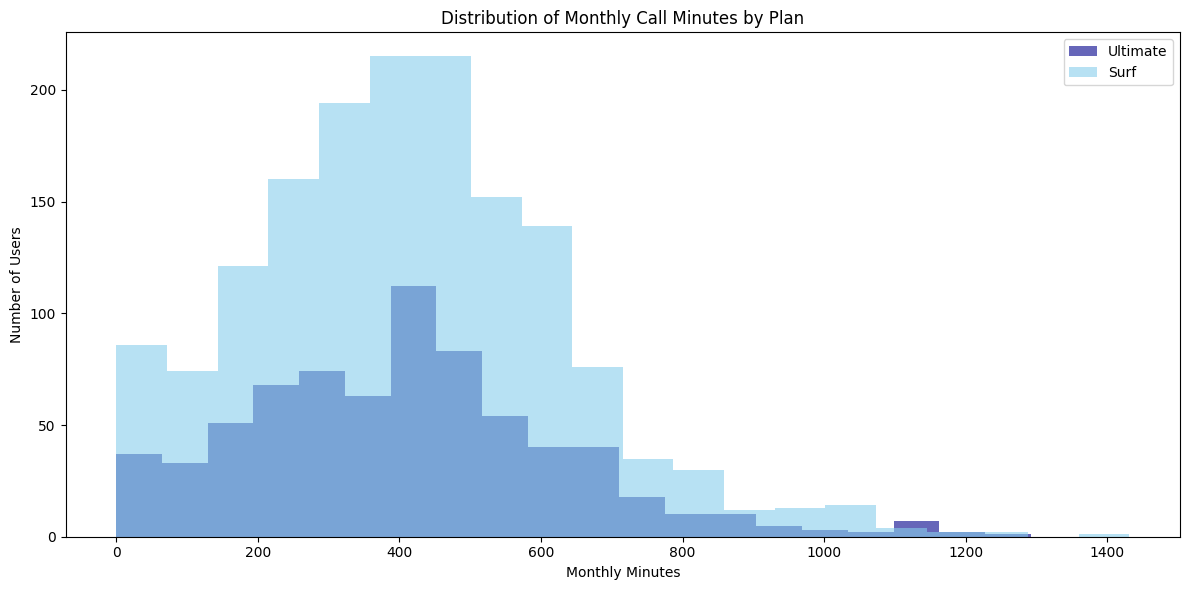

In [140]:
# Compare the number of monthly minutes used by users in each plan using a histogram

# Define colors for each plan
plan_colors = {
    'Surf': 'skyblue',
    'Ultimate': 'darkblue'
}

# Ensure plan names match the dictionary format
df_calls_merged['plan'] = df_calls_merged['plan'].str.capitalize()

# Group by user, plan, and month to calculate total monthly minutes
monthly_minutes = (
    df_calls_merged.groupby(['user_id', 'plan', 'year_month_c'])['duration']
    .sum()
    .reset_index()
)

# Create histogram
plt.figure(figsize=(12,6))

for plan in monthly_minutes['plan'].unique():
    df_plan = monthly_minutes[monthly_minutes['plan'] == plan]
    
    plt.hist(
        df_plan['duration'],      # monthly minutes
        bins=20,                 # number of bins
        alpha=0.6,               # transparency to see overlap
        color=plan_colors[plan], # assigned color per plan
        label=plan
    )

# Add labels and title
plt.xlabel('Monthly Minutes')
plt.ylabel('Number of Users')
plt.title('Distribution of Monthly Call Minutes by Plan')
plt.legend()
plt.tight_layout()
plt.show()

📊 Conclusion – Bar Chart (Average Call Duration by Plan vs Month)

The bar chart shows that both Surf and Ultimate users have a very similar average call duration across all months, generally between 6 and 7 minutes. Although Surf users are slightly higher in some months, the difference is minimal (less than one minute). This indicates consistent behavior between both plans over time.

In [141]:
# Calculate overall mean and variance of monthly call duration across all users

mean_monthly = monthly_minutes['duration'].mean()
variance_monthly = monthly_minutes['duration'].var()

print(f"Average monthly call duration: {mean_monthly:.2f} minutes")
print(f"Variance of monthly call duration: {variance_monthly:.2f}")

Average monthly call duration: 411.49 minutes
Variance of monthly call duration: 48088.30


In [142]:
# Mean and variance by plan
stats_by_plan = (
    monthly_minutes.groupby('plan')['duration']
    .agg(['mean', 'var'])
    .round(2)
)

stats_by_plan

,mean,var
plan,,
Surf,412.10,47001.25
Ultimate,410.18,50510.63


The overall average monthly call duration is around 411 minutes, which aligns with the peak observed in the histogram. However, the high variance indicates significant variability in user behavior, meaning that while many users cluster around the average, there are also users with very low and very high usage levels.

C:\Users\Liz\AppData\Local\Temp\ipykernel_4756\3507165881.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


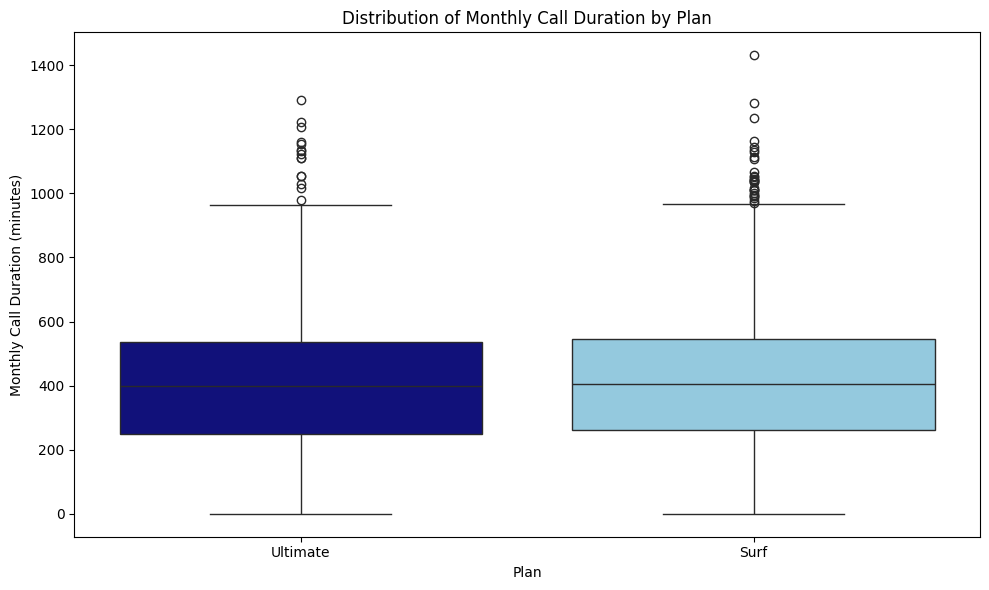

In [143]:
# Visualize the distribution of monthly call duration using a boxplot

plt.figure(figsize=(10,6))

sns.boxplot(
    data=monthly_minutes,
    x='plan',
    y='duration',
    palette=plan_colors
)

# Add labels and title
plt.xlabel('Plan')
plt.ylabel('Monthly Call Duration (minutes)')
plt.title('Distribution of Monthly Call Duration by Plan')

plt.tight_layout()
plt.show()

📊 Conclusion – Boxplot (Monthly Call Duration by Plan)

The boxplot shows that both Surf and Ultimate plans have very similar median values and overall distribution. The spread of the data is comparable, indicating similar variability in user behavior. This reinforces that there is no significant difference in monthly call duration between the two plans

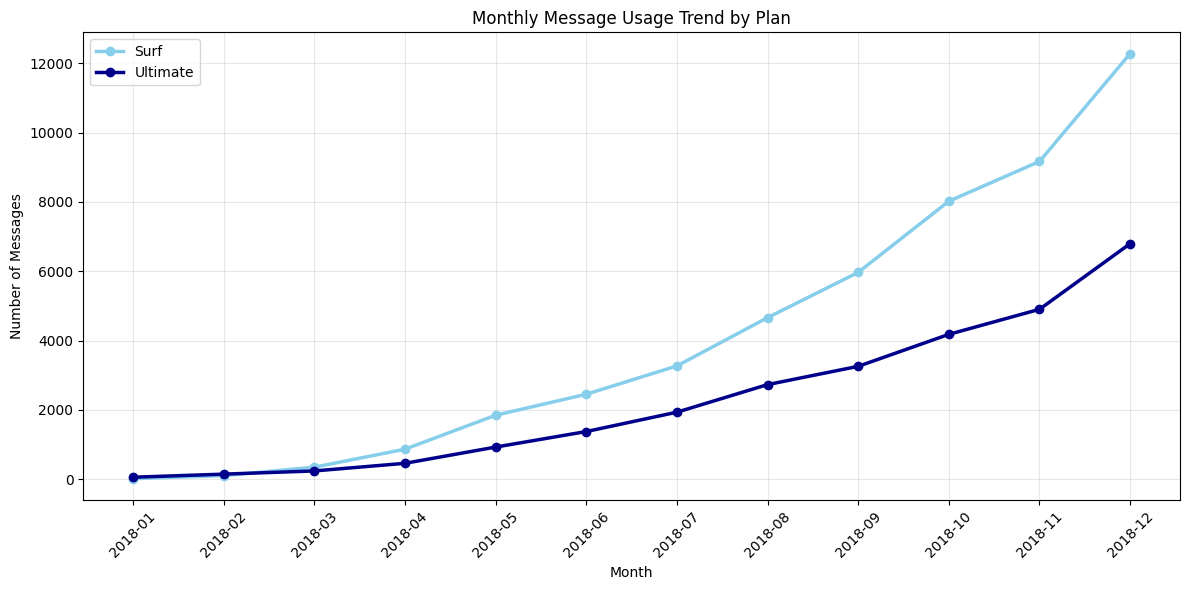

In [151]:
# Merge message data with user plan information

df_messages_merged = df_messages.merge(
    df_users[['user_id', 'plan']],
    on='user_id',
    how='left'
)

# Ensure consistent plan naming
df_messages_merged['plan'] = df_messages_merged['plan'].str.capitalize()

# Define colors for each plan
plan_colors = {'Surf': 'skyblue', 'Ultimate': 'darkblue'}

# Group messages by plan and month
monthly_messages = (
    df_messages_merged.groupby(['plan', 'year_month_m'])['id']
    .count()
    .reset_index(name='messages')
)

# Create line chart
plt.figure(figsize=(12,6))

for plan in monthly_messages['plan'].unique():
    df_plan = monthly_messages[monthly_messages['plan'] == plan]
    
    # Sort months to ensure correct order
    df_plan = df_plan.sort_values('year_month_m')
    
    plt.plot(
        df_plan['year_month_m'],
        df_plan['messages'],
        marker='o',
        linewidth=2.5,
        label=plan,
        color=plan_colors[plan]
    )

# Add labels and title
plt.xlabel('Month')
plt.ylabel('Number of Messages')
plt.title('Monthly Message Usage Trend by Plan')

# Improve x-axis readability
plt.xticks(rotation=45)

# Add subtle grid for better readability
plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

📊 Conclusion – Line Chart (Monthly Messages Sent by Plan)

The line chart shows a clear upward trend in message usage for both plans throughout the year. However, Surf consistently has a higher number of messages compared to Ultimate in every month. The gap between the two plans increases over time, especially in the later months, indicating that Surf users are significantly more active in messaging. This suggests that messaging behavior differs more noticeably between plans than call duration, and may play a more important role in plan usage patterns.

In [154]:
# Calculate number of messages per user per month
monthly_user_messages = (
    df_messages_merged.groupby(['user_id', 'plan', 'year_month_m'])['id']
    .count()
    .reset_index(name='monthly_messages')
)

# Calculate average messages per user by plan
avg_messages_per_user = (
    monthly_user_messages.groupby('plan')['monthly_messages']
    .mean()
    .round(2)
)

avg_messages_per_user

plan
Surf        40.11
Ultimate    46.30
Name: monthly_messages, dtype: float64

📊 Conclusion – Monthly Messages Average per Plan (Refined)

The line chart shows that the total number of messages is consistently higher for the Surf plan across all months. However, further analysis reveals that this difference is not driven by higher individual usage. In fact, Ultimate users send more messages per user on average. Therefore, the higher total message volume in Surf is primarily due to a larger number of users rather than more intensive messaging behavior.

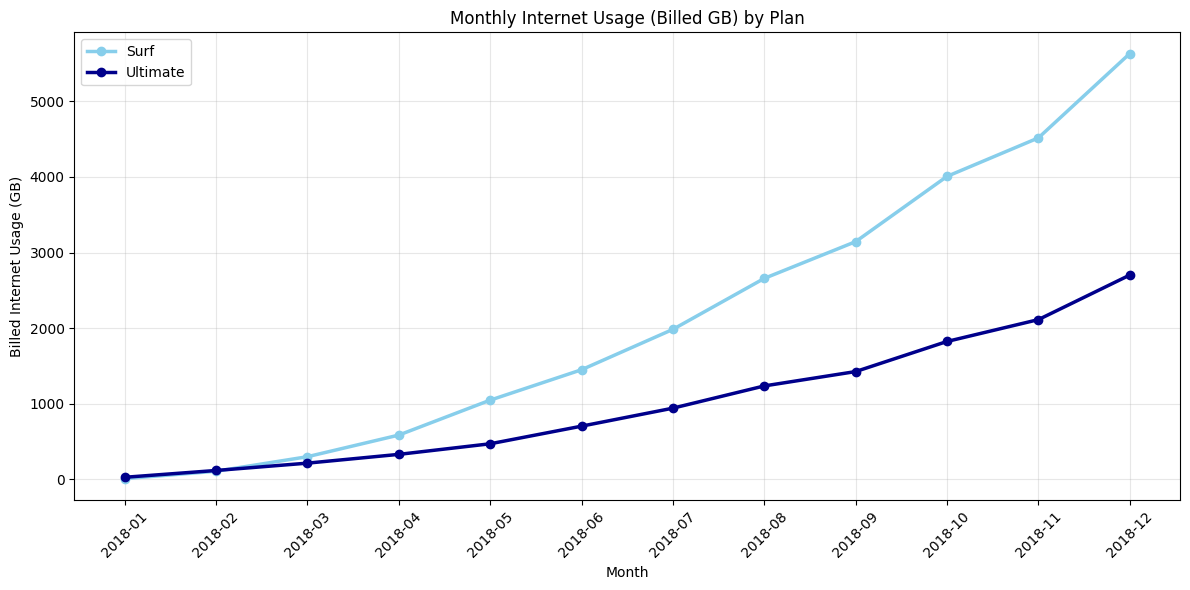

In [155]:
# Merge internet sessions with user plan information

df_internet_merged = df_internet.merge(
    df_users[['user_id', 'plan']],
    on='user_id',
    how='left'
)

# Ensure consistent plan naming
df_internet_merged['plan'] = df_internet_merged['plan'].str.capitalize()

# Define colors for each plan
plan_colors = {'Surf': 'skyblue', 'Ultimate': 'darkblue'}

# Group internet usage by plan and month (sum of MB used)
monthly_internet = (
    df_internet_merged.groupby(['plan', 'year_month_i'])['mb_used']
    .sum()
    .reset_index()
)

# Convert MB to billed GB (round up)
monthly_internet['gb_billed'] = np.ceil(monthly_internet['mb_used'] / 1024)

# Create line chart
plt.figure(figsize=(12,6))

for plan in monthly_internet['plan'].unique():
    df_plan = monthly_internet[monthly_internet['plan'] == plan]
    
    # Ensure correct month order
    df_plan = df_plan.sort_values('year_month_i')
    
    plt.plot(
        df_plan['year_month_i'],
        df_plan['gb_billed'],
        marker='o',
        linewidth=2.5,
        label=plan,
        color=plan_colors[plan]
    )

# Labels and title (same style as previous chart)
plt.xlabel('Month')
plt.ylabel('Billed Internet Usage (GB)')
plt.title('Monthly Internet Usage (Billed GB) by Plan')

# Improve readability
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.legend()
plt.tight_layout()
plt.show()

📊 Conclusion – Line Chart (Monthly Internet Usage – Billed GB)

The total billed internet usage is consistently higher for Surf compared to Ultimate. This may be influenced by a larger number of users subscribed to the Surf plan, which increases the total consumption. Therefore, the observed difference in total usage does not necessarily imply higher usage per user, but rather reflects overall plan adoption and aggregated behavior

In [156]:
# Calculate billed GB per user per month
monthly_user_internet = (
    df_internet_merged.groupby(['user_id', 'plan', 'year_month_i'])['mb_used']
    .sum()
    .reset_index()
)

# Convert to billed GB (round up)
monthly_user_internet['gb_billed'] = np.ceil(monthly_user_internet['mb_used'] / 1024)

# Calculate average billed GB per user by plan
avg_gb_per_user = (
    monthly_user_internet.groupby('plan')['gb_billed']
    .mean()
    .round(2)
)

avg_gb_per_user

plan
Surf        16.83
Ultimate    17.33
Name: gb_billed, dtype: float64

📊 Conclusion – Average Billed GB per User (Refined)

The average billed internet usage per user is slightly higher for Ultimate than for Surf. However, the difference is minimal, indicating that individual data consumption is very similar between the two plans. Therefore, the higher total internet usage observed in the Surf plan is likely driven primarily by a larger number of users rather than significantly different usage behavior per user.

           count       mean        std   min   25%    50%    75%     max
plan                                                                    
surf      1573.0  60.706408  55.388042  20.0  20.0  40.36  80.36  590.37
ultimate   720.0  72.313889  11.395108  70.0  70.0  70.00  70.00  182.00


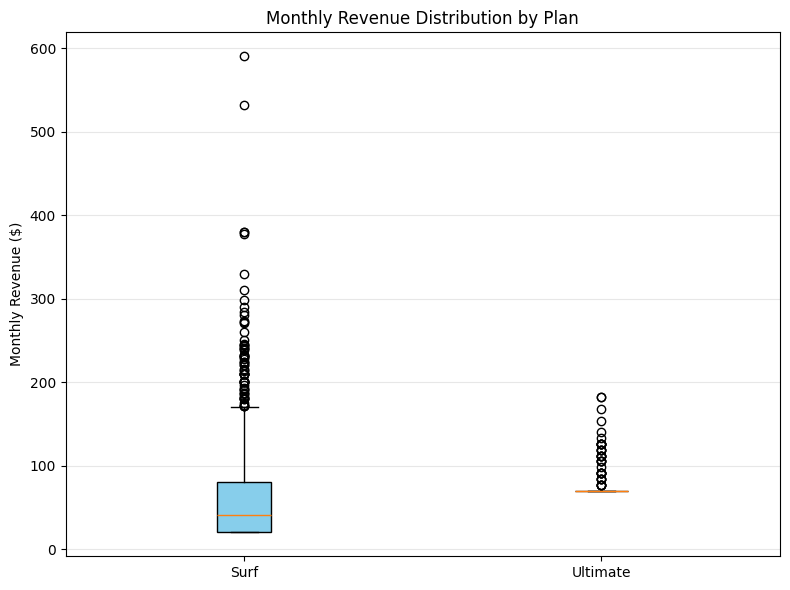

In [157]:
# Summary statistics of monthly revenue by plan

print(usage.groupby('plan')['monthly_revenue'].describe())

plt.figure(figsize=(8,6))

# Boxplot for Surf plan
plt.boxplot(
    usage[usage['plan'].str.capitalize() == 'Surf']['monthly_revenue'],
    vert=True,
    patch_artist=True,
    positions=[1],
    boxprops=dict(facecolor='skyblue')
)

# Boxplot for Ultimate plan
plt.boxplot(
    usage[usage['plan'].str.capitalize() == 'Ultimate']['monthly_revenue'],
    vert=True,
    patch_artist=True,
    positions=[2],
    boxprops=dict(facecolor='darkblue')
)

# Labels and title
plt.xticks([1, 2], ['Surf', 'Ultimate'])
plt.ylabel('Monthly Revenue ($)')
plt.title('Monthly Revenue Distribution by Plan')

# Add light grid for readability
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

📊 Conclusion – Monthly Revenue Distribution by Plan (Box Plot)

The Surf plan shows a much higher variability in monthly revenue, with many users paying only the base fee, while others significantly exceed plan limits, resulting in high outliers. In contrast, the Ultimate plan exhibits a more stable revenue distribution, where most users consistently pay the fixed monthly fee and only a few generate additional charges. Although the average revenue is higher for Ultimate, the Surf plan demonstrates greater revenue dispersion and the potential to generate high revenue peaks from overage charges.

📊 Hypothesis Testing – Monthly Revenue by Plan

Null Hypothesis (H0):
The average monthly revenue for Surf users is equal to that of Ultimate users.
H0: μ_Surf = μ_Ultimate

Alternative Hypothesis (H1):
The average monthly revenue for Surf users is different from that of Ultimate users.
H1: μ_Surf ≠ μ_Ultimate

Significance level (alpha):
α = 0.05

In [159]:
from scipy.stats import ttest_ind

# Revenue by plan
surf_revenue = usage[usage['plan'].str.capitalize() == 'Surf']['monthly_revenue']
ultimate_revenue = usage[usage['plan'].str.capitalize() == 'Ultimate']['monthly_revenue']

# Welch’s t-test (unequal variances)
t_stat, p_value = ttest_ind(surf_revenue, ultimate_revenue, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value}")

# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a statistically significant difference in average revenue between plans.")
else:
    print("Fail to reject H0: No significant difference in average revenue between plans.")

T-statistic: -7.952
P-value: 3.170390548113574e-15
Reject H0: There is a statistically significant difference in average revenue between plans.


📊 Monthly Revenue by Plan Conclusion

The p-value is far below the significance level (0.05), leading to the rejection of the null hypothesis. This indicates that the difference in average monthly revenue between the Surf and Ultimate plans is statistically significant and not due to random variation. Additionally, the negative t-statistic suggests that Ultimate users generate higher revenue on average compared to Surf users.

📊 Hypothesis Testing – Revenue by Region (NY-NJ vs Other Regions)

Null Hypothesis (H0):
The average monthly revenue of users in the New York–Newark–Jersey City metropolitan area is equal to the average monthly revenue of users in other regions.
H0: μ_NY-NJ = μ_Other

Alternative Hypothesis (H1):
The average monthly revenue of users in the New York–Newark–Jersey City metropolitan area is different from that of users in other regions.
H1: μ_NY-NJ ≠ μ_Other

Significance level (α):
α = 0.05

In [164]:
from scipy.stats import ttest_ind

# Merge revenue with city
usage_city = usage.merge(df_users[['user_id', 'city']], on='user_id', how='left')

# Normalize text
usage_city['city_clean'] = usage_city['city'].str.lower()

# Define NY-NJ group
ny_nj_mask = usage_city['city_clean'].str.contains('new york-newark-jersey')

ny_nj_revenue = usage_city[ny_nj_mask]['monthly_revenue']
other_revenue = usage_city[~ny_nj_mask]['monthly_revenue']

# Check sample sizes (important)
print("NY-NJ users:", len(ny_nj_revenue))
print("Other regions users:", len(other_revenue))

# T-test
t_stat, p_value = ttest_ind(ny_nj_revenue, other_revenue, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.5f}")

# Decision
alpha = 0.05

if p_value < alpha:
    print("Reject H0: There is a significant difference in revenue between NY-NJ and other regions.")
else:
    print("Fail to reject H0: No significant difference between regions.")

NY-NJ users: 377
Other regions users: 1916
T-statistic: -2.131
P-value: 0.03353
Reject H0: There is a significant difference in revenue between NY-NJ and other regions.


In [ ]:
# Welch’s T-test: NY-NJ vs Other Regions

# Merge revenue with city
usage_city = usage.merge(df_users[['user_id', 'city']], on='user_id', how='left')

# Clean text
usage_city['city_clean'] = usage_city['city'].str.lower()

# Create region label
usage_city['region'] = usage_city['city_clean'].apply(
    lambda x: 'NY-NJ' if 'new york-newark-jersey' in x else 'Other'
)


# 1. Basic summary stats

summary = usage_city.groupby('region')['monthly_revenue'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
)

print("📊 Revenue Summary by Region")
print(summary)



# 2. Average revenue per user-month (visual check)

print("\n📌 First rows of grouped data:")
print(
    usage_city[['user_id', 'region', 'monthly_revenue']].head(10)
)



# 3. Distribution check (optional quick look)

print("\n📌 Sample values NY-NJ:")
print(usage_city[usage_city['region'] == 'NY-NJ']['monthly_revenue'].head())

print("\n📌 Sample values Other regions:")
print(usage_city[usage_city['region'] == 'Other']['monthly_revenue'].head())

📊 Revenue Summary by Region
        count       mean  median        std   min     max
region                                                   
NY-NJ     377  59.921353   51.77  43.537865  20.0  280.00
Other    1916  65.222771   70.00  47.170414  20.0  590.37

📌 First rows of grouped data:
   user_id region  monthly_revenue
0     1000  Other            70.00
1     1001  Other            20.00
2     1001  Other            20.00
3     1001  Other            90.09
4     1001  Other            60.00
5     1001  Other            60.00
6     1002  Other            20.00
7     1002  Other            60.00
8     1002  Other            20.00
9     1003  Other           158.12

📌 Sample values NY-NJ:
56     20.00
57     38.84
75     20.00
76    100.00
77     20.00
Name: monthly_revenue, dtype: float64

📌 Sample values Other regions:
0    70.00
1    20.00
2    20.00
3    90.09
4    60.00
Name: monthly_revenue, dtype: float64


📊 Conclusion – NY-NJ vs Other Regions Revenue Analysis

The statistical test (Welch’s t-test) shows a significant difference in average monthly revenue between users in the NY-NJ region and users from other regions (p-value = 0.03353 < 0.05). Therefore, we reject the null hypothesis.

The descriptive statistics confirm this result: NY-NJ users generate lower average monthly revenue (59.92) compared to users in other regions (65.22). This difference is also reflected in the median values (51.77 vs 70.00), suggesting a consistent pattern of lower revenue per user in the NY-NJ region.

Although the difference of approximately $5 per user per month may seem small at an individual level, it can become significant when scaled across a large user base, potentially leading to a meaningful impact on total revenue for the company.

📊 Global Conclusion (Updated)
📌 Overall Conclusion

This analysis evaluated user behavior and revenue patterns across different plans (Surf vs Ultimate) and geographic regions (NY-NJ vs other regions).

The results show statistically significant differences in average monthly revenue between both plans and between regions. Ultimate users generate higher average revenue compared to Surf users, indicating a stronger monetization per user.

However, the boxplot analysis revealed an important insight: although Surf users generally generate lower average revenue, some Surf users exceed plan limits significantly and end up paying more than the base plan price. This creates high variability in Surf revenue, with a wider spread and more extreme values compared to Ultimate users, whose payments are more stable and concentrated around the base fee.

On a regional level, users in the NY-NJ region generate slightly lower average revenue than users in other regions. Although the difference is approximately $5 per user per month, this gap can become meaningful when scaled across a large customer base.

Overall, the findings suggest that revenue differences are driven by both user behavior and plan structure. Surf shows higher variability and occasional high-paying users, while Ultimate generates more consistent revenue. These insights can help the company optimize pricing strategies and better understand customer value across segments.